<a href="https://colab.research.google.com/github/Luke-Dev-Tech/Business_intelligence_and_data-mining/blob/main/BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Personality Analysis using Machine Learning and Data Mining**

# **[1] Introduction**

The purpose of this project was to investigate how customers behave and forecast the reaction to a marketing campaign for a retail client who has a limited contact budget. The business issue here is that the target is inefficient.

The marketing team need an effective method to prioritize customers for the next campaign as well as customize messages and offers to each type of customer.

We used the "Customer Personality Analysis" dataset from kaggle.com. This dataset had 2,240 customer records and 29 variables. Each row in the data represented one customer. The columns contained demographic information and income, household composition, customer enrollment date, recency (the time since last interaction), spending across product categories, number of purchases made by channel, whether or not they accepted the previous campaign, if they filed complaints and a binary response variable for the most recent campaign.

This project answered three questions:

1. What customer segments exist based on their value, recency, purchase frequency and behavior by channel.

2. What were the strongest correlations to campaign response.

3. Who are the best customers to pursue with a ranked list based on the predicted likelihood of responding.

# **[2] Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# **[3] Load Dataset**

##Dataset Description

The dataset used is the Customer Personality Analysis dataset from Kaggle, consisting of:

2,240 customer records
29 features


###Feature categories:

Demographics: Age, Income, Education, Marital Status
Spending behaviour: Amount spent on products (wine, meat, etc.)

Customer activity: Number of purchases, recency
Marketing response: Campaign acceptance (binary target)

Dataset Type:
Structured (tabular)
Mixed data types (numerical + categorical)

In [ ]:
url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"

In [ ]:
df = pd.read_csv(url, sep='\t')
df.head()
df.tail()
display(df.info())
display(df.describe())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


# **[4] Data Cleaning & Feature Engineering**

## [4.1] Viewing the missing data


In [ ]:
print("Start of Part 4 shape:", df.shape)
print("Top missing columns before:\n", df.isna().sum().sort_values(ascending=False).head(15))

Start of Part 4 shape: (2240, 29)
Top missing columns before:
 Income              24
ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64


The start records the dataset size and missing values before cleaning for a comparison after

## [4.2] Create Age Feature

This section creates a reproducible age feature using the dataset timeline, then caps unrealistic ages.

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
df["Year_Birth"] = pd.to_numeric(df["Year_Birth"], errors="coerce")

as_of = df["Dt_Customer"].max()
df["Age"] = as_of.year - df["Year_Birth"]
df["Age"] = df["Age"].clip(lower=18, upper=100)

print("Age reference date:", as_of.date())
print("Age min/max:", df["Age"].min(), df["Age"].max())

Age reference date: 2014-06-29
Age min/max: 18 100


## [4.3] Convert Date Column

This Converts Dt_Customer to datetime and shows how many rows ended up failing parsing.

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
print("Null Dt_Customer:", int(df["Dt_Customer"].isna().sum()))

Null Dt_Customer: 0


## [4.4] Drop Unnecessary Columns

This sections removes identifier and constant columns and checks duplicate customers, then prints how many columns remain.

**Handle Missing Values Part A**

In [ ]:
before_cols = df.shape[1]

df = df.drop(columns=["ID"], errors="ignore")

for c in ["Z_CostContact", "Z_Revenue"]:
    if c in df.columns and df[c].nunique(dropna=False) <= 1:
        df = df.drop(columns=[c])

print("Columns before:", before_cols, "after:", df.shape[1])

Columns before: 30 after: 27


In [ ]:
print("Columns after:", df.shape[1])

Columns after: 27


Here we fill the missing values using mean for numeric, mode for categorical, and keeps binary flags as 0 or 1. We use mean on the numeric columns to ensure that all customers are included in the analysis and to avoid bias in the results due to the removal of rows.

In [ ]:
print(df.isna().sum().sort_values(ascending=False).head(15))

binary_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Complain","Response"]
binary_cols = [c for c in binary_cols if c in df.columns]
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].mode()[0]).astype(int)

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in binary_cols]
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

print("Total nulls after:", int(df.isna().sum().sum()))

Income               24
Education             0
Year_Birth            0
Marital_Status        0
Kidhome               0
Teenhome              0
Dt_Customer           0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumDealsPurchases     0
dtype: int64
Total nulls after: 0


**Handle Missing Values Part B**

Then part B Fixes invalid negative values for fields that should never be negative.

In [ ]:
nonneg_cols = [
    "Income","Recency",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"
]
for c in nonneg_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = 0

**Handle Missing Values Part C**

Finally, this part clips any extreme income and spend outliers to reduce their impact on clustering and models.

In [ ]:
def clip_percentiles(s, low=0.01, high=0.99):
    return s.clip(s.quantile(low), s.quantile(high))

for c in ["Income","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]:
    if c in df.columns:
        df[c] = clip_percentiles(df[c], 0.01, 0.99)

## [4.5] Final check after cleaning

In [ ]:
print("Final shape:", df.shape)
print("Top missing columns after:\n", df.isna().sum().sort_values(ascending=False).head(15))

Final shape: (2240, 27)
Top missing columns after:
 Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumDealsPurchases    0
dtype: int64


# **[5] Exploratory Data Analysis (EDA)**

## [5.1] Boxplot Analysis (visualization)

###Why use Boxplot analysis

The boxplots show that many variables are on different scales and that some have outliers, which supports the use of scaling before clustering and modelling.

In [ ]:
import seaborn as sns

features = [
    "Income",
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    "NumWebPurchases",
    "NumStorePurchases",
    "Recency",
    "Age"
]


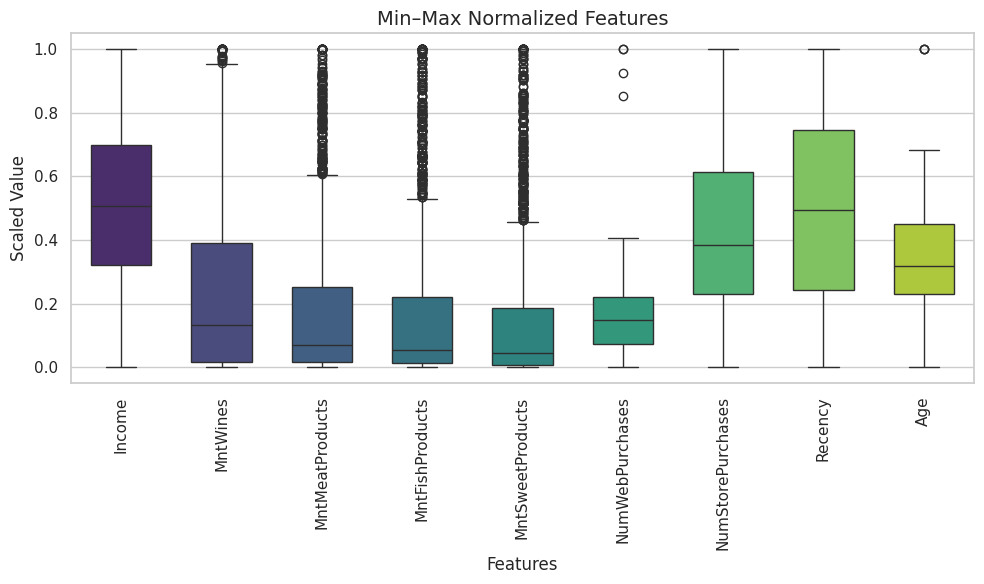

In [ ]:
# Min–Max
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df_mm = pd.DataFrame(mm.fit_transform(df[features]), columns=features)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_mm,
    palette="viridis",
    width=0.6
)

plt.title("Min–Max Normalized Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Scaled Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

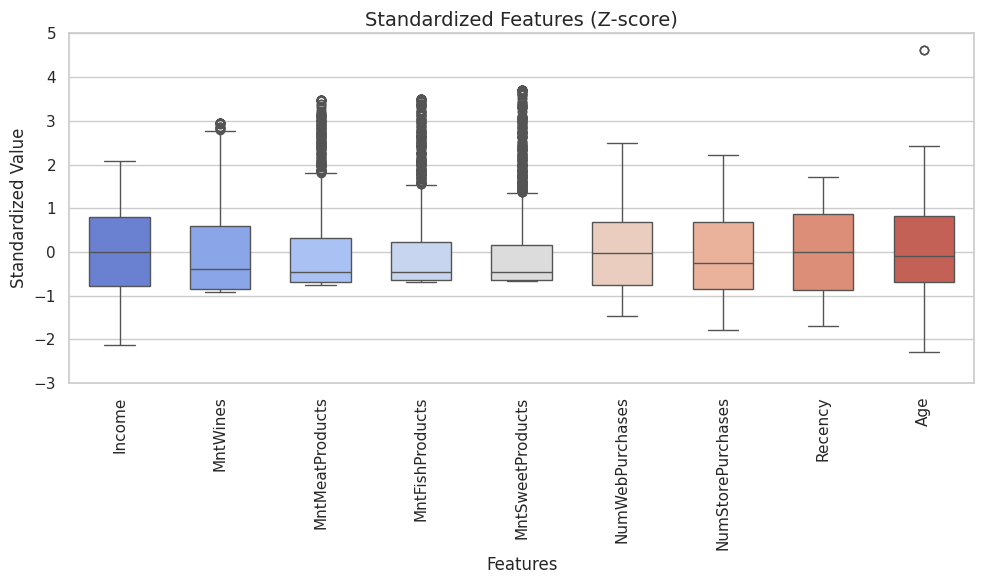

In [ ]:
# Standardized
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_sc = pd.DataFrame(sc.fit_transform(df[features]), columns=features)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_sc,
    palette="coolwarm",
    width=0.6
)

plt.ylim([-3,5])
plt.title("Standardized Features (Z-score)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Standardized Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

**Business Insights**

**Wine**: Wine is the most reliable product because almost all customers buy it consistently.

**High Spenders**: Revenue in meat, fish, and sweets relies heavily on a very small group of high-spending VIP customers.

**Sales Channels**: Most customers shop predictably in physical stores, while online sales depend entirely on a few highly active users.

**Customer Habits**: Customers have steady incomes and predictable return visits, making them perfect targets for automated subscription services.


## [5.2] Income Distribution

###Why use income distribution

The income distribution is slightly right-skewed, again confirming the presence of higher-income outliers and validating the decision to log-transform and clip income before clustering.

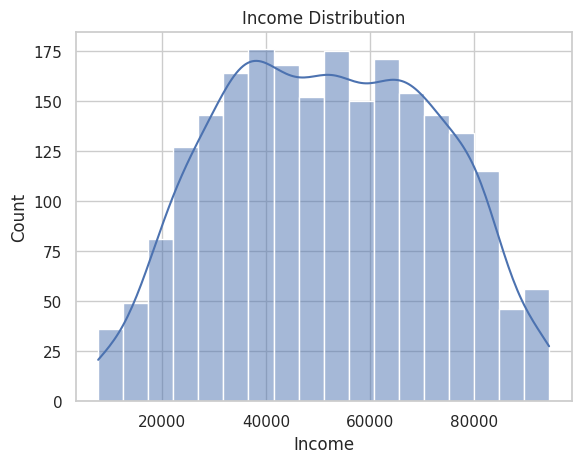

In [ ]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()


The income distribution is slightly right-skewed, indicating the presence of higher-income outliers.

## [5.3] Spending Correlation Heatmap

###Why use spending correlation heatmap

The heatmap suggests strong positive relationships among some spending categories, especially wine and meat spending, and indicates that higher-value customers often spend across multiple categories rather than in only one area. This supports the creation of Total_Spending as an engineered feature and also helps explain why customer value emerges so strongly in the clustering results.

In [ ]:
import pandas as pd

# Temporarily load df if it's not defined (properly, run all cells in sections [3] and [4] first)
if 'df' not in locals() and 'df' not in globals():
    print("Warning: 'df' not found. Loading raw data. Please ensure all upstream cells are run for proper data cleaning.")
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')

spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending_df = df[spending_cols]

corr_matrix = spending_df.corr()

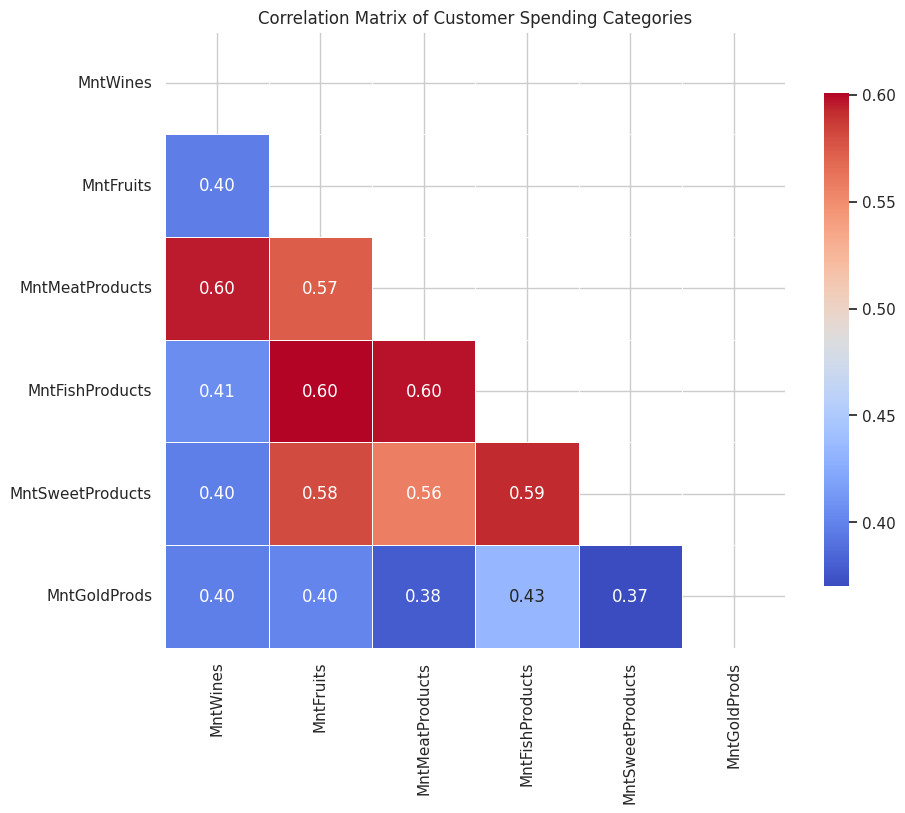

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of Customer Spending Categories")
plt.show()

*   The correlation heatmap reveals strong positive relationships between
wine and meat product spending, suggesting customers who purchase wine frequently also tend to spend more on meat products.
*   Moderate correlations across multiple categories indicate that high-value customers typically purchase across diverse product groups rather than specialising in a single category.
*   This supports the hypothesis that higher-income customers exhibit broader purchasing behaviour.


## [5.4] Target Variable Distribution (Class Imbalance)

###Why use class imbalance

The class distribution is a critical insight for the prediction task. Only 14.9% of customers responded, while 85.1% did not. This means the prediction problem is imbalanced. As a result, accuracy alone is not enough to judge model performance.

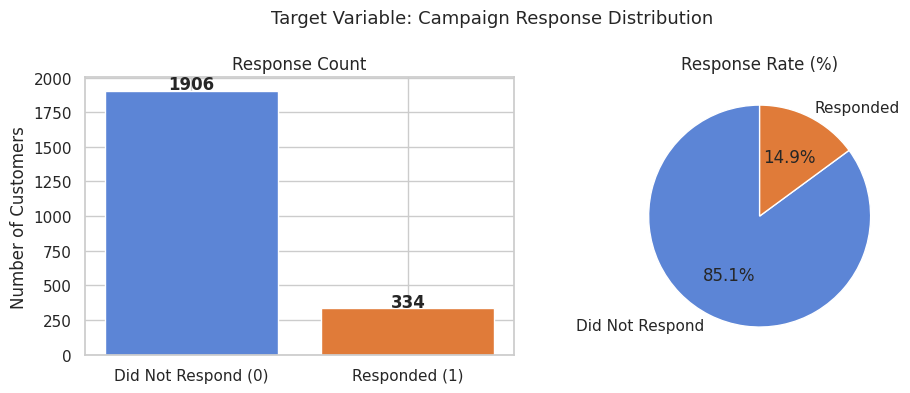

Response rate: 14.9%  |  Non-response rate: 85.1%


In [ ]:
response_counts = df['Response'].value_counts()
response_pct = df['Response'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(['Did Not Respond (0)', 'Responded (1)'], response_counts.values,
          color=['#5c85d6', '#e07b39'])
ax[0].set_title('Response Count')
ax[0].set_ylabel('Number of Customers')
for i, v in enumerate(response_counts.values):
    ax[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

ax[1].pie(response_pct.values, labels=['Did Not Respond', 'Responded'],
          autopct='%1.1f%%', colors=['#5c85d6', '#e07b39'], startangle=90)
ax[1].set_title('Response Rate (%)')

plt.suptitle('Target Variable: Campaign Response Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Response rate: {response_pct[1]:.1f}%  |  Non-response rate: {response_pct[0]:.1f}%")


## [5.5] Feature–Response Correlation (Point-Biserial)


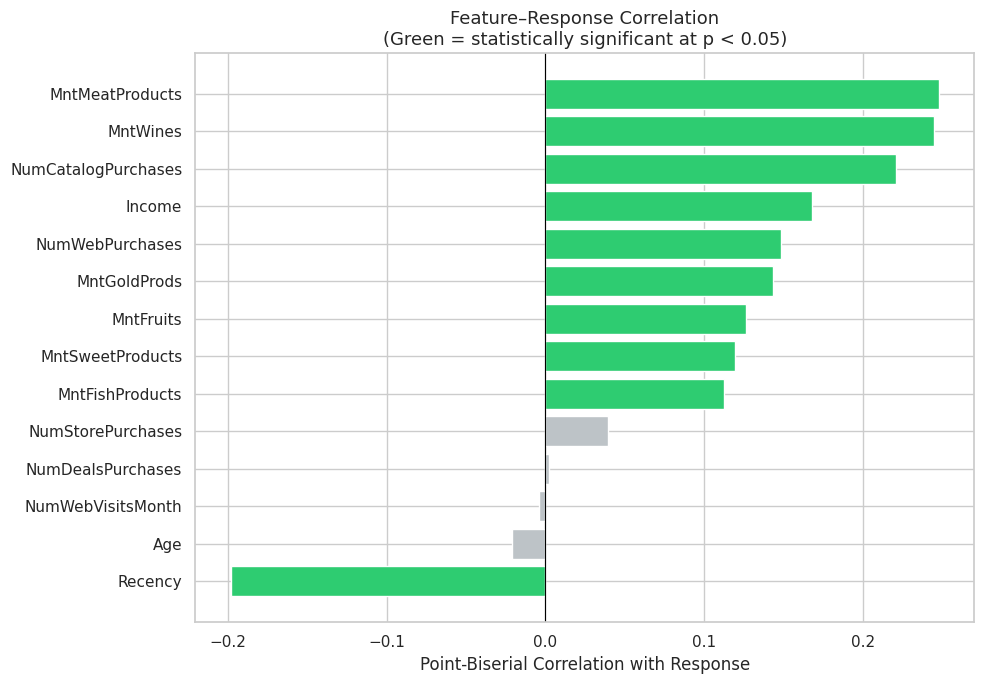

,Correlation,p-value,Significant
MntMeatProducts,0.2479,0.0000,True
MntWines,0.2449,0.0000,True
NumCatalogPurchases,0.2208,0.0000,True
Income,0.1682,0.0000,True
NumWebPurchases,0.1487,0.0000,True
MntGoldProds,0.1436,0.0000,True
MntFruits,0.1263,0.0000,True
MntSweetProducts,0.1196,0.0000,True
MntFishProducts,0.1128,0.0000,True
NumStorePurchases,0.0394,0.0625,False


In [ ]:
from scipy import stats

numeric_candidates = [
    'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Age',
    'Total_Spending', 'Total_Purchases', 'Spending_per_Purchase'
]
existing = [c for c in numeric_candidates if c in df.columns]

results = {}
for col in existing:
    valid = df[['Response', col]].dropna()
    r, p = stats.pointbiserialr(valid['Response'], valid[col])
    results[col] = {'Correlation': round(r, 4), 'p-value': round(p, 4)}

corr_df = pd.DataFrame(results).T.sort_values('Correlation', ascending=False)
corr_df['Significant'] = corr_df['p-value'] < 0.05

colors = ['#2ecc71' if sig else '#bdc3c7' for sig in corr_df['Significant']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(corr_df.index, corr_df['Correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with Response')
ax.set_title('Feature–Response Correlation\n(Green = statistically significant at p < 0.05)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(corr_df)

## [5.6] Log-Odds Linearity Check


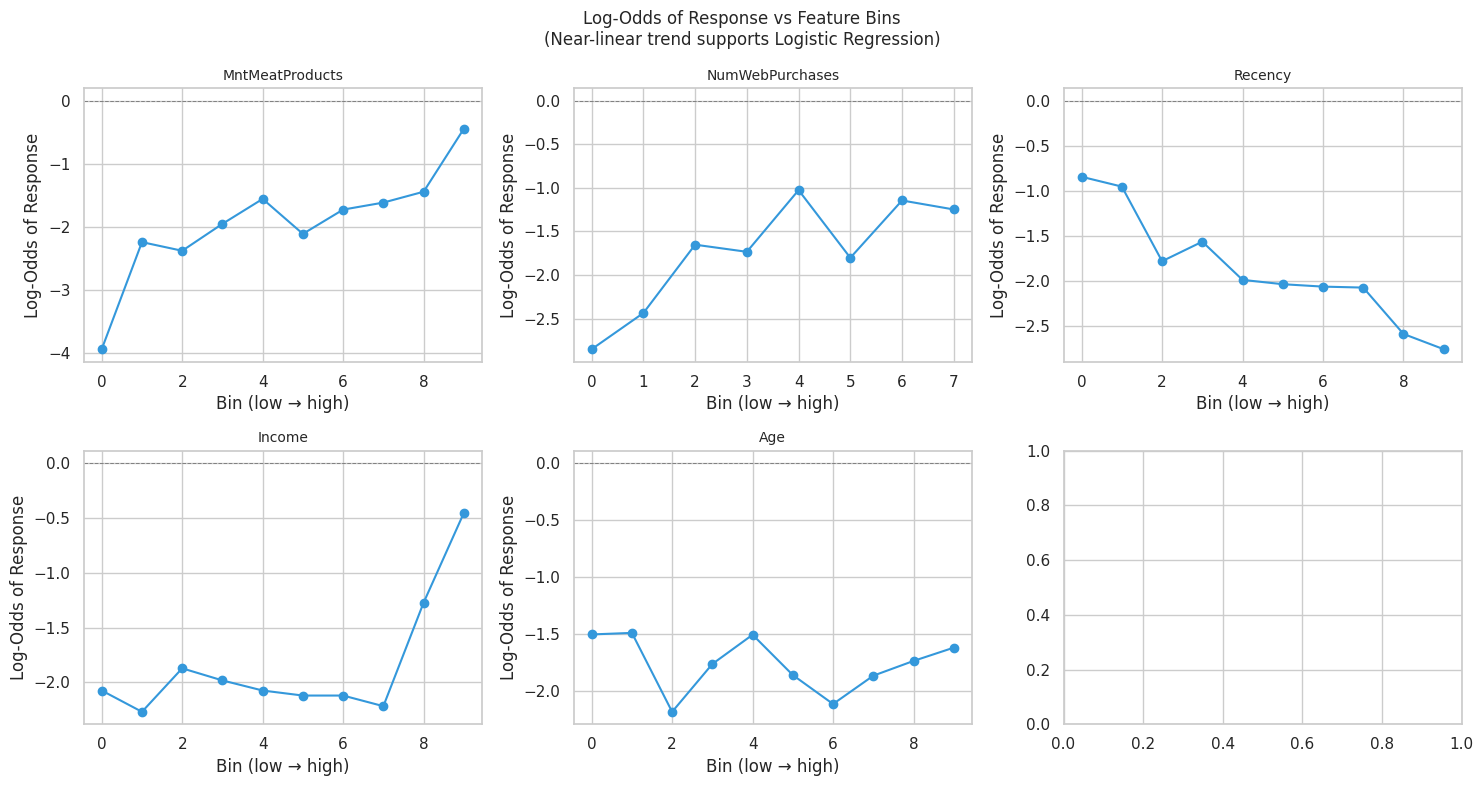

In [ ]:
key_features = ['MntMeatProducts', 'NumWebPurchases', 'Total_Spending',
                'Recency', 'Income', 'Age']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    temp = df[[feat, 'Response']].dropna().copy()
    temp['bin'] = pd.qcut(temp[feat], q=10, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)['Response'].agg(['mean', 'count'])
    grouped = grouped[grouped['count'] >= 5]
    rate = grouped['mean'].clip(1e-4, 1 - 1e-4)
    log_odds = np.log(rate / (1 - rate))

    axes[i].plot(range(len(log_odds)), log_odds.values, marker='o', color='#3498db')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Bin (low → high)')
    axes[i].set_ylabel('Log-Odds of Response')
    axes[i].axhline(0, color='grey', linestyle='--', linewidth=0.7)

plt.suptitle('Log-Odds of Response vs Feature Bins\n(Near-linear trend supports Logistic Regression)', fontsize=12)
plt.tight_layout()
plt.show()

## [5.7] Feature Distributions by Response Class


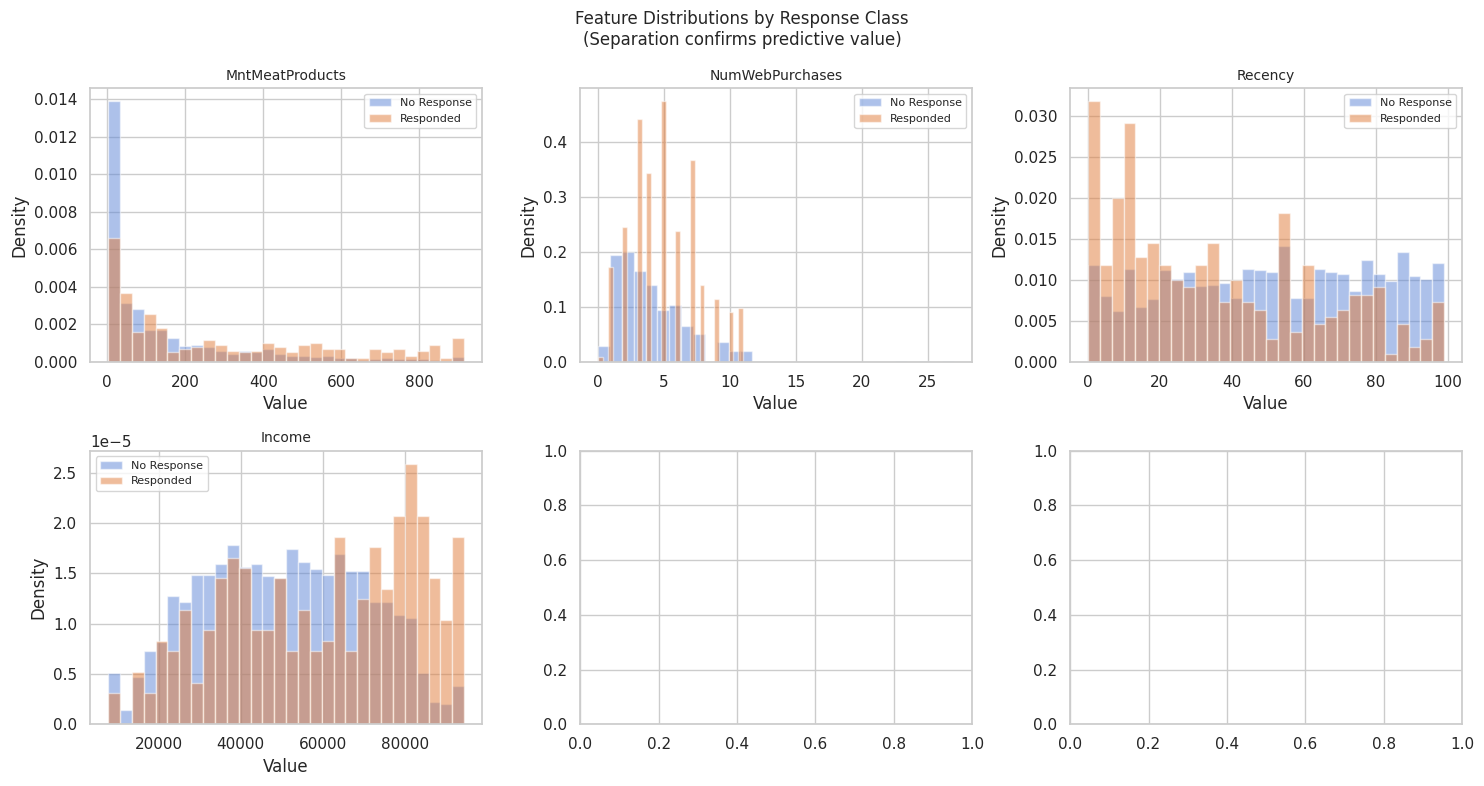

In [ ]:
top_features = ['Total_Spending', 'MntMeatProducts', 'NumWebPurchases',
                'Recency', 'Income', 'Spending_per_Purchase']
top_features = [f for f in top_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for resp, color, label in [(0, '#5c85d6', 'No Response'), (1, '#e07b39', 'Responded')]:
        subset = df[df['Response'] == resp][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Response Class\n(Separation confirms predictive value)', fontsize=12)
plt.tight_layout()
plt.show()


MntMeatProducts, NumWebPurchases, and Total_Spending show near-monotonic upward trends in log-odds. Which means a clear linear signal Logistic Regression can exploit directly. Recency shows a consistent downward trend, confirming its strong negative linear relationship with response. Age and Income show flatter or irregular patterns at the extremes, which is where Decision Tree adds value through threshold-based splits that do not rely on linearity.

## [5.8] Non-Linear Patterns and Interaction Effects



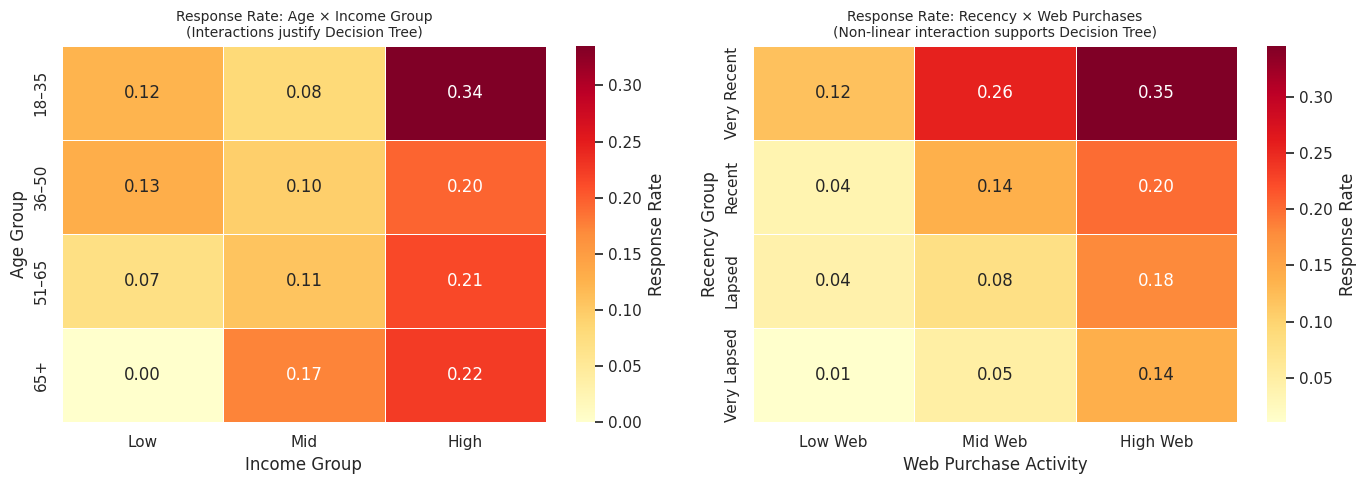

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Response rate by Age × Income quadrant ---
df_tmp = df[['Age', 'Income', 'Response']].dropna().copy()
df_tmp['Age_group'] = pd.cut(df_tmp['Age'], bins=[17, 35, 50, 65, 100],
                              labels=['18–35', '36–50', '51–65', '65+'])
df_tmp['Income_group'] = pd.qcut(df_tmp['Income'], q=3,
                                  labels=['Low', 'Mid', 'High'])

pivot = df_tmp.groupby(['Age_group', 'Income_group'], observed=True)['Response'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Response Rate'})
axes[0].set_title('Response Rate: Age × Income Group\n(Interactions justify Decision Tree)', fontsize=10)
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Age Group')

# --- Plot 2: Response rate by Recency × Web Purchases ---
df_tmp2 = df[['Recency', 'NumWebPurchases', 'Response']].dropna().copy()
df_tmp2['Recency_group'] = pd.qcut(df_tmp2['Recency'], q=4,
                                    labels=['Very Recent', 'Recent', 'Lapsed', 'Very Lapsed'])
df_tmp2['Web_group'] = pd.cut(df_tmp2['NumWebPurchases'], bins=[-1, 1, 4, 100],
                               labels=['Low Web', 'Mid Web', 'High Web'])

pivot2 = df_tmp2.groupby(['Recency_group', 'Web_group'], observed=True)['Response'].mean().unstack()
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'Response Rate'})
axes[1].set_title('Response Rate: Recency × Web Purchases\n(Non-linear interaction supports Decision Tree)', fontsize=10)
axes[1].set_xlabel('Web Purchase Activity')
axes[1].set_ylabel('Recency Group')

plt.tight_layout()
plt.show()

## Model's Selection and interpretation (By AI Suggestion Edit this)

K-Means (Clustering)
K-Means was chosen because the segmentation task is entirely unsupervised — no predefined customer labels exist. The clustering features are all continuous and numerical, which makes Euclidean distance meaningful and well-defined. The data forms compact, separable groups in the feature space, which is exactly the structure K-Means is designed to exploit. It also assigns every customer to a clear segment, which is a practical requirement for campaign targeting, and its outputs map directly onto interpretable business categories that non-technical stakeholders can act on immediately.

Logistic Regression (Classification)
Logistic Regression was chosen as the primary classifier because the relationship between the strongest predictors and the binary target is largely linear, meaning the model's core assumption is satisfied by this data. More importantly, it produces odds ratios that translate directly into business language — explaining why a customer is likely to respond, not just whether they will. This interpretability is a core requirement of the project. On a dataset of this size, it also generalises reliably without overfitting, and it pairs naturally with SMOTE to handle the class imbalance present in the target variable.

Decision Tree (Classification)
The Decision Tree was chosen as a complementary classifier because the data contains non-linear interaction effects that a linear model cannot capture — the response rate at specific combinations of features is far higher than either feature suggests independently. Decision Trees handle this naturally through threshold-based splits without requiring any distributional assumptions. They also produce human-readable decision rules that campaign managers can interpret and apply directly, which keeps the model useful beyond just generating predictions.

# **[6] Clustering (K-Means)**

##Why choose K-means

K-Means was an appropriate choice because the segmentation problem is unsupervised: there are no predefined labels for customer groups. The aim is to discover hidden structure in customer behaviour, and K-Means is one of the most suitable methods for identifying compact, interpretable segments in standardized numerical data.

K-Means was the best fit for this dataset because the clustering variables were continuous, numerical, and standardized, which suits the algorithm well. It also matched the business need to place every customer into a clear, actionable segment through simple hard assignments. Although hierarchical clustering can provide a dendrogram, it is less practical for repeatable business use and future customer assignment. DBSCAN is better for irregular cluster shapes and noise detection, but it may leave some customers unassigned, while Gaussian Mixture Models add unnecessary complexity through probabilistic membership. Overall, K-Means offered the strongest balance of interpretability, efficiency, and practical business value.



## [6.1] Data Preprocessing

### Feature Engineering

#### Why use feature engineering

This step was needed because clustering works better when the variables reflect clear behavioural meaning. If too many raw columns are used, especially correlated ones, distance-based methods like K-Means can become noisy and harder to interpret. These engineered features simplify the data while preserving the core business meaning.

In [ ]:
# Total Spending
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
    )

In [ ]:
# Purchase Frequency
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']

  )

In [ ]:
# Spending Per Purchase
df['Spending_per_Purchase'] = df['Total_Spending'] / (df['Total_Purchases'] + 1)

### Reformatting

#### Why Reformat

K-Means should not be applied blindly to all available columns. The project deliberately selected a small set of variables that best represent the customer in terms of value, engagement, and life stage.
This is important because K-Means uses distance to group similar observations. If irrelevant, duplicated, or mixed-type variables are included, the distances become less meaningful. By focusing on these five features, the clustering becomes more interpretable and more connected to the business question.


In [ ]:
import pandas as pd

# Ensure Age feature exists before selection
# if 'Age' not in df.columns:
#     df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
#     as_of = df['Dt_Customer'].max()
#     df['Age'] = as_of.year - df['Year_Birth']
#     df['Age'] = df['Age'].clip(lower=18, upper=100)

cluster_features = df[[
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases',
    'Spending_per_Purchase'
]]

display(cluster_features)

### Handle Outliers

In [ ]:
cluster_features = cluster_features[
    cluster_features['Income'] < cluster_features['Income'].quantile(0.99)
]

####Why Use Handle Outliners

This step was needed because K-Means is highly sensitive to outliers. Since the algorithm uses Euclidean distance, a few extreme observations can pull the cluster centres away from the real structure of the data. In customer data, very high-income outliers may distort segmentation and create misleading groups.
This suits the dataset because income is often right-skewed in real customer populations. Removing extreme values helps the model focus on the main customer base instead of being dominated by rare extreme cases.

### Log Transform Income

In [ ]:
cluster_features['Income'] = np.log1p(cluster_features['Income'])

####This was needed because income usually has a skewed distribution, and large values can dominate the distance calculation. The log transformation reduces the gap between moderate and extremely large values without removing the variable entirely.
This is especially suitable for K-Means because distance-based models perform better when one variable does not overpower the others. It makes the income variable more balanced relative to age, spending, and purchase frequency.

### Normalization And Scale Features Properly

In [ ]:
# [Edited By: Han]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)
scaled_features[:]

####K-Means does not understand units. If one feature is measured in tens of thousands, such as income, and another is measured in small counts, such as purchases, the larger-scale variable will dominate the clustering. Standardisation puts all features on the same scale.
This is the correct choice for this dataset because the variables used for clustering are measured in very different ranges. Without scaling, the clusters would mostly reflect income rather than overall customer behaviour.

## [6.2] Dimentionalitiy Reduction (PCA) Before Clustering

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

####This step was needed for two reasons. First, it reduces redundancy between correlated features. Second, it makes the customer structure easier to visualise in two dimensions.
This is a sensible choice for this dataset because customer spending and purchase variables are often correlated. PCA helps compress that shared information into a simpler structure. It does not replace the original data, but it helps reveal the main behavioural patterns.

## [6.3] Train Model

In [ ]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(n_clusters=3, random_state=42)
clusters = model_kmeans.fit_predict(pca_features)
df.loc[cluster_features.index, 'Cluster'] = clusters



The PCA-based clustering reveals three distinct behavioural groups:

• High-income, high-spending customers  
• Moderate spenders with balanced purchasing behaviour  
• Lower-income, low-frequency buyers  

The dimensionality reduction ensures clusters are not distorted by correlated variables and improves separation clarity.

## [6.4] Cluster Evaluation

### Elbow Method (Initial Cluster Estimation)

### Silhouette Score (Cluster Quality)

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal Clusters")
plt.show()

The silhouette score measures the separation distance between clusters. Higher values indicate better-defined clusters. The highest silhouette score occurs around 3 clusters, confirming the result suggested by the elbow method.

### Davies–Bouldin Index (Cluster Separation)

In [ ]:
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = davies_bouldin_score(scaled_features, labels)
    db_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), db_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.title("Cluster Evaluation using Davies-Bouldin Index")
plt.show()

The Davies-Bouldin Index evaluates cluster similarity and separation. Lower scores indicate better cluster separation. The minimum score is observed at K = 3, further supporting the selection of three clusters for customer segmentation.

## [6.5] Visualise Clusters in 2D

## [6.6] Apply K-Means

In this cell, K-Means is fitted again on the scaled features, and the resulting cluster labels are written back into df.
This is an important step because it produces the final cluster assignment used later in the notebook. The earlier PCA version helped exploration, while this step applies the final segmentation to the customer dataset itself.
This is methodologically suitable because the final segmentation should be based on the properly prepared behavioural variables.

In [ ]:
from sklearn.cluster import KMeans

# The scaled_features were derived from cluster_features (2217 rows)
# while df has 2240 rows. We use the index to match them correctly.
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df.loc[cluster_features.index, 'Cluster'] = clusters

## [6.7] Cluster Size and Summary Analysis

The final clusters contain:

* Cluster 0: 601 customers
* Cluster 1: 946 customers
* Cluster 2: 670 customers

These groups are reasonably balanced, which is a good sign. None of the clusters are so small that they appear accidental, and none are so large that they absorb all structure.

### 1. Cluster Size Distribution

In [ ]:
# Count number of customers in each cluster
cluster_size = df['Cluster'].value_counts().sort_index()
cluster_size

### 2. Visualisation

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    cluster_size.values,
    labels=[f"Cluster {i}" for i in cluster_size.index],
    autopct='%1.1f%%',
    startangle=90
)

# Create donut effect
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Cluster Distribution (%)")
plt.show()

### 3. Cluster Summary Statistics (Mean, Median, Std)

The means show:

* Cluster 0 has the highest income, highest spending,
and highest purchase frequency.
* Cluster 1 has the lowest income, lowest spending, and lowest engagement.
* Cluster 2 sits in the middle, but is the oldest on average.

This is exactly what good clustering should produce: distinct, interpretable groups that make business sense.

In [ ]:
cluster_summary = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].agg(['mean','median','std'])

cluster_summary

### 4. Simplified Mean Comparison

In [ ]:
cluster_mean = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].mean()

cluster_mean

### 5. Heatmap of Cluster Behaviour

In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize cluster means
scaler = StandardScaler()
normalized_data = scaler.fit_transform(cluster_mean)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=cluster_mean.columns,
    index=cluster_mean.index
)

plt.figure(figsize=(10,6))

sns.heatmap(
    normalized_df,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Standardized Value'}
)

plt.title("Normalized Cluster Behaviour Heatmap", fontsize=14, weight='bold')
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Cluster Summary

The summary statistics provide a detailed view of customer characteristics within each cluster. By analysing mean, median, and standard deviation values, we can understand the typical behaviour and variability within each segment.

Clusters with higher average income and spending represent high-value customers, while clusters with lower values indicate less engaged customers.

### Behavioural Differences

Comparing clusters across key features highlights clear differences:

* Income differences reflect varying purchasing power
* Spending differences indicate customer value
* Purchase frequency differences show engagement levels

These variations confirm that the clustering has successfully separated customers into distinct behavioural groups.

## [6.8] Cluster Profile

In [ ]:
cluster_profile = df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age'
]].mean().round(2)

cluster_profile

### 1. Normalised Cluster Profile

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
normalized = scaler.fit_transform(cluster_profile)

cluster_profile_normalized = pd.DataFrame(
    normalized,
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

cluster_profile_normalized

### 2. Z-Score Deviation Plot of Cluster Profiles

In [ ]:
overall_mean = df[['Income','Total_Spending','Total_Purchases','Age']].mean()

z_score = (cluster_profile - overall_mean) / df[['Income','Total_Spending','Total_Purchases','Age']].std()

z_score.plot(kind='bar', figsize=(10,6))

plt.title("Cluster Deviation from Overall Average (Z-Score)")
plt.axhline(0)
plt.ylabel("Standard Deviations")
plt.xticks(rotation=0)

plt.show()

### 3. Feature Comparison Bar Plot

In [ ]:
cluster_profile.plot(kind='bar', figsize=(10,6))

plt.title("Cluster Profile Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

### 4. Ranking Clusters by Key Behaviour

In [ ]:
cluster_profile['Spending_Rank'] = cluster_profile['Total_Spending'].rank(ascending=False)

cluster_profile.sort_values(by='Total_Spending', ascending=False)

The cluster profile analysis provides a comprehensive view of how customer segments differ in terms of key behavioural features such as income, total spending, purchasing activity, and age.

Using the Z-score deviation approach, the results highlight how each cluster compares to the overall average. Positive values indicate that a cluster performs above average for a feature, while negative values indicate below-average behaviour. This allows for a clearer comparison of relative differences between customer segments.

The analysis shows that each cluster has distinct characteristics. Some clusters demonstrate higher income and spending levels, indicating high-value and highly engaged customers, while others show lower purchasing activity and spending, representing less engaged customer groups. Differences in purchase frequency further reflect varying levels of customer interaction with the business.

Overall, the cluster profile confirms that the K-Means algorithm has successfully segmented customers into meaningful groups with distinct behavioural patterns. These insights can be used to support targeted marketing strategies and improve customer engagement by focusing on the specific needs of each segment.


Why K-Means Was the Correct Choice

K-Means was the correct clustering method for this chapter because:

* There were no known customer segment labels, so an unsupervised method was required.
* The input to clustering was transformed into numeric, standardised, behaviour-focused features, which is exactly what K-Means needs.
* The dataset is moderate in size, so K-Means is efficient and practical.
* The output is easy to explain to business users.

Comparison with Other Clustering Methods

* Hierarchical Clustering could have been used, but it is less practical for repeatable operational use and becomes harder to scale. It is useful for dendrogram analysis, but less convenient when the goal is clear segment assignment.

* DBSCAN is good for irregular cluster shapes and outlier detection, but your customer features were prepared into a compact behavioural space. In this setting, K-Means is simpler and more appropriate.

* Gaussian Mixture Models could provide soft membership probabilities, but they are harder to explain and unnecessary for a project that needs clear segment labels.

# [7] Logistic Regression



This section focuses on using **Logistic Regression** to predict customer response to marketing campaigns. Given the binary nature of the target variable ('Response' - either 0 for no response or 1 for response), Logistic Regression is a suitable choice for this classification task.

We will analyze how various customer attributes, such as income, age, and spending habits on different product categories, influence the likelihood of a customer responding to a campaign. The goal is to build a predictive model that can identify potential responders, allowing for more targeted and efficient marketing strategies.

## [7.1.1] Feature Selection

In [ ]:
X = df.drop(columns=['Year_Birth', 'Response', 'Dt_Customer'])
X[X.select_dtypes(include='number').columns] = X.select_dtypes(include='number').fillna(X.select_dtypes(include='number').median())
X[X.select_dtypes(include='object').columns] = X.select_dtypes(include='object').fillna(X.select_dtypes(include='object').mode().iloc[0])
X = pd.get_dummies(X, columns=['Education', 'Marital_Status'], drop_first=True)


display(X.columns)

In [ ]:
y = df['Response']

## [7.1.2] Train-Test Split

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


display(X_train_scaled)

## [7.2] Training and Testing

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

## [7.3] Scores

In [ ]:
log_model.score(X_train_scaled, y_train)

In [ ]:
log_model.score(X_test_scaled, y_test)

## [7.4] Loss and Confusion Matrixs

In [ ]:
loss = confusion_matrix(y_test, y_pred_log)
loss

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

## [7.5] Interpretation of Logistic Regression


In [ ]:
log_model.coef_

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient' : log_model.coef_[0]
})


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

coef_sorted = coefficients.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize = (10,8))
bars = plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'])
plt.axvline(x=0, color = 'grey', linestyle='--')
plt.title('Cofficient in Logistic Regression')
plt.xlabel("Cofficient Value (Effect on Respond)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Campaign Response – Coefficient Direction Summary
*   Recency and in-store purchasing are the clearest negative signals.
*   Partnered customers (married/together) and those with teenagers at home are less likely to respond.
*   Meat spending, web visits, and prior campaign acceptance are the strongest positive signals.
*   Education level has a modest positive effect, particularly at PhD level.
*   Most spending categories, income, and age have negligible influence.









In [ ]:
log_odds = np.round(log_model.coef_[0], 4)
log_odds

In [ ]:
pd.DataFrame({'log odds': log_odds}, index = X.columns)

In [ ]:
odds = np.round(np.exp(log_odds), 2)
odds = pd.DataFrame({'odds': odds}, index = X.columns)
odds

The odds ratios provide insights into how each feature impacts the likelihood of a customer responding to a marketing campaign, holding all other factors constant:

--> Customers who have not engaged recently are 59% less likely to respond (OR: 0.41) — re-engagement should be addressed before targeting

--> Customers with a history of accepting past campaigns are up to 63% more likely to respond again (OR: 1.37–1.63) — prioritise this segment for future campaigns

--> High meat product spenders are nearly twice as likely to respond (OR: 1.92), suggesting a strong link between premium food purchasing and campaign receptiveness

--> Frequent website visitors are 81% more likely to respond (OR: 1.81) — digital engagement is a reliable indicator of campaign interest

--> Married and cohabiting customers are approximately 40% less likely to respond (OR: 0.58, 0.60), suggesting campaigns may need tailored messaging for this demographic

--> Customers with higher education levels, particularly postgraduate, show notably greater responsiveness (OR: PhD 1.69, Master 1.24)

--> In-store-focused shoppers are 36% less likely to respond (OR: 0.64), indicating campaign channels may not align with their purchasing behaviour

--> Income, age, and complaint history show negligible influence (OR: ~1.0) and should not be primary segmentation criteria

**Key Business Strategy by the Odds of Logisitic Regression**

The most efficient targeting strategy is to focus campaign spend on recently active, digitally engaged customers who have previously responded to campaigns — this group is consistently and significantly more likely to convert, particularly among high meat and gold product spenders who signal premium purchasing behaviour. Lapsed customers and partnered households represent poor short-term ROI and require a fundamentally different approach before standard campaign targeting can be effective. Rather than broad-based outreach, the data strongly supports precision segmentation as the path to higher conversion at lower cost.

## [7.6] Handling Class Inblanace

### SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is used to address class imbalance by generating synthetic samples for the minority class. This helps prevent the model from becoming biased towards the majority class, thereby improving its ability to identify the minority class (e.g., customers who respond to campaigns).

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set shape: {Counter(y_train)}")

print(f"Resampled training set shape: {Counter(y_train_smote)}")

log_model_smote = LogisticRegression(max_iter=1000, random_state=42)
log_model_smote.fit(X_train_smote, y_train_smote)

y_pred_log_smote = log_model_smote.predict(X_test_scaled)

In [ ]:
log_model_smote.score(X_train_smote, y_train_smote)

In [ ]:
log_model_smote.score(X_test_scaled, y_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log_smote))
print(classification_report(y_test, y_pred_log_smote))

# **[8] Decision Tree**


This section uses a Decision Tree to predict whether a customer will respond to the businesses marketing campaign. The model is tuned using all usable features, class-weight options, and a validation-based threshold searching. The aim here is to improve identifying likely responders while keeping the model interpretable and useful for campaign targeting.

## [8.1] Preparing the features and targets



In [ ]:
drop_cols = ["ID", "Response", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth"]
drop_cols = [c for c in drop_cols if c in df.columns]

X_tree = df.drop(columns=drop_cols).copy()
y_tree = df["Response"].copy()

cat_cols = X_tree.select_dtypes(include=["object", "category"]).columns
X_tree = pd.get_dummies(X_tree, columns=cat_cols, drop_first=True, dtype=int)

print("Feature matrix shape:", X_tree.shape)
print("Target distribution:\n", y_tree.value_counts())

This section creates the feature set for the Decision Tree and defines Response as the target variable. All the usable customer features are included so the model has a fuller view of customer profile, spending behaviour and campaign history. Categorical variables are also encoded so they can be used in the model.

## [8.2]  Creating training, validation and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test_tree, y_temp, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

X_train_tree, X_val_tree, y_train_tree, y_val_tree = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train_tree.shape)
print("Validation set:", X_val_tree.shape)
print("Test set:", X_test_tree.shape)

This step splits the data into training, validation and test sets. Stratify is used so the class balance stays similar across all sets. The validation set is then used to tune the classification threshold without leaking information from the test set.

## [8.3] Evaluation helper




In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob)
    }

def top20_metrics(y_true, y_prob):
    tmp = pd.DataFrame({
        "Actual_Response": y_true.values,
        "Response_Probability": y_prob
    }).sort_values("Response_Probability", ascending=False)

    cutoff_index = int(np.ceil(len(tmp) * 0.20))
    top20 = tmp.head(cutoff_index)

    top20_response_rate = top20["Actual_Response"].mean()
    overall_response_rate = tmp["Actual_Response"].mean()
    lift = top20_response_rate / overall_response_rate if overall_response_rate > 0 else 0

    return {
        "Top20 Response Rate": top20_response_rate,
        "Overall Response Rate": overall_response_rate,
        "Lift": lift
    }

This step creates reusable functions to evaluate the model and calculate targeting performance.

## [8.4] Training and tuning the base Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}],
    "ccp_alpha": [0.0, 0.0005, 0.001, 0.005]
}

tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1
)

tree_search.fit(X_train_tree, y_train_tree)
model_tree = tree_search.best_estimator_

print("Best parameters:", tree_search.best_params_)

This step tunes the Decision Tree using cross-validation. PR AUC is used as the main tuning metric because the response class is imbalanced, so it is more useful than accuracy for this business problem.

## [8.5] Tuning the classification threshold on the validation set

In [ ]:
val_prob = model_tree.predict_proba(X_val_tree)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    val_pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_val_tree, val_pred),
        "Precision": precision_score(y_val_tree, val_pred, zero_division=0),
        "Recall": recall_score(y_val_tree, val_pred, zero_division=0),
        "F1 Score": f1_score(y_val_tree, val_pred, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table = threshold_table.sort_values(
    by=["F1 Score", "Recall", "Accuracy"],
    ascending=False
).reset_index(drop=True)

best_threshold = threshold_table.loc[0, "Threshold"]

display(threshold_table)
print("Selected threshold:", best_threshold)

This step tests different probability thresholds on the validation set and selects the one that gives the best balance of F1 score and Recall. This is important because the default threshold of 0.5 may not be the best choice for an imbalanced response problem.

## [8.6] Evaluating the final Decision Tree on the test set

In [ ]:
test_prob_tree = model_tree.predict_proba(X_test_tree)[:, 1]
y_pred_tree = (test_prob_tree >= best_threshold).astype(int)
y_prob_tree = test_prob_tree

final_scores = get_metrics(y_test_tree, y_pred_tree, y_prob_tree)

for metric, value in final_scores.items():
    print(f"{metric}: {value:.3f}")

This step tests the final tuned model on unseen data using the selected threshold. This gives the final performance scores for the section.



## [8.7] Confusion matrix and classification report

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print(classification_report(y_test_tree, y_pred_tree, zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test_tree, y_pred_tree))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_tree,
    y_pred_tree,
    cmap="Blues",
    ax=ax
)
ax.set_title("Decision Tree - Confusion Matrix")
ax.grid(False)
plt.tight_layout()
plt.show()

This step shows how well the final model predicted the response classes. The confusion matrix helps show whether the model is correctly identifying responders, which is important for campaign targeting.

## [8.8] Visualising the final Decision Tree and important features





In [ ]:

from sklearn.tree import plot_tree
from IPython.display import display
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 10), dpi=140)

artists = plot_tree(
    model_tree,
    feature_names=X_train_tree.columns,
    class_names=["No Response", "Response"],
    filled=True,
    rounded=True,
    fontsize=6,
    proportion=True,
    max_depth=3,
    ax=ax
)


for artist in artists:
    if hasattr(artist, "get_text"):
        txt = artist.get_text().strip()
        if "(...)" in txt or txt == "..." or txt == "":
            artist.set_visible(False)
            if hasattr(artist, "arrow_patch") and artist.arrow_patch is not None:
                artist.arrow_patch.set_visible(False)

ax.set_title("Final Decision Tree", fontsize=12, pad=18, loc="center")
ax.set_anchor("C")
plt.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.08)
plt.show()
plt.close(fig)

tree_importance = pd.DataFrame({
    "Feature": X_train_tree.columns,
    "Importance": model_tree.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

display(tree_importance.head(15))
None

This section shows the final Decision Tree structure and the most important features the model used.

## [8.9] Applying a targeting rule

In [ ]:
targeting_scores = top20_metrics(y_test_tree, y_prob_tree)

print("Customers targeted in top 20 percent:", int(np.ceil(len(y_test_tree) * 0.20)))
print("Response rate in top 20 percent:", round(targeting_scores["Top20 Response Rate"], 3))
print("Overall response rate:", round(targeting_scores["Overall Response Rate"], 3))
print("Lift over overall response rate:", round(targeting_scores["Lift"], 2))

This last step ranks customers by predicted response probability and selects the top 20 % for outreach. This is more useful for the marketing campaign than treating the model as a strict yes or no classifier.

## [8.10] Business insights

The Decision Tree was chosen because it fits the characteristics of this dataset well. The data includes a mix of spending behaviour, campaign history, recency, household information, and encoded customer profile variables. A Decision Tree can handle this mix of features well, capture non-linear patterns, and still remain easy to interpret, which is useful for a campaign-targeting problem where the business needs clear decision rules.

Based on the latest results, the model works best as a targeting tool. The top 20 percent of customers ranked by predicted response had a response rate of 44.4 percent compared with 15.0 percent overall, giving a lift of 2.97. This shows the model can help the retailer use campaign budget more efficiently by prioritising customers with the highest likelihood of response.

# **[9] Prediction model comparison**

## [9.1] Calculate Multiple Performance Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test_tree, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test_tree, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test_tree, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test_tree, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]), # Corrected to use X_test_scaled
        roc_auc_score(y_test_tree, model_tree.predict_proba(X_test_tree)[:,1]) # Changed X_test to X_test_tree and y_test to y_test_tree
    ]
})

comparison

## [9.2] Visual Comparison

In [ ]:
comparison.set_index('Model').plot(kind='bar')

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## [9.3] Confusion Matrix Comparison

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,4))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0])
ax[0].set_title("Logistic Regression")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
ax[0].grid(False)

# Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=ax[1])
ax[1].set_title("Decision Tree")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
ax[1].grid(False)

plt.tight_layout()
plt.show()

The model comparison evaluates the performance of Logistic Regression and Decision Tree using several metrics including accuracy, precision, recall, F1-score, and ROC-AUC.

Accuracy shows the overall percentage of correct predictions made by each model. A higher accuracy indicates that the model correctly predicts customer responses more often.

Precision measures how many of the predicted positive responses are actually correct. This is important when identifying customers who are likely to respond to marketing campaigns.

Recall shows how well the model identifies customers who actually responded to the campaign. A higher recall means the model is better at detecting potential responders.

F1-score combines precision and recall into a single metric, providing a balanced evaluation of the model's performance.

The ROC-AUC score evaluates how well the model can distinguish between customers who respond and those who do not. A higher value indicates better overall classification ability.

The confusion matrices further show the number of correct and incorrect predictions made by each model. By analysing these results, we can observe which model provides more reliable predictions for customer responses.

Overall, the model with higher values across these evaluation metrics demonstrates better performance for predicting marketing campaign responses in this dataset.

##[9.4] Classification report


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_tree))

##[9.5] ROC curve and AUC

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_pred_log)
RocCurveDisplay.from_predictions(y_test, y_pred_tree)

The ROC curve shows the trade-off between the True Positive Rate and the False Positive Rate at different threshold values. A model with a curve closer to the top-left corner has better classification performance. In this case, both models perform only slightly better than random guessing, since their curves stay close to the diagonal line.
The model with AUC = 0.64 performs better than the model with AUC = 0.56, because it has a higher ability to distinguish between the positive and negative classes. However, both AUC values are relatively low, which suggests that neither model has strong discriminative power.

## [9.6] Feature Importance Comparison

In [ ]:
# Decision Tree feature importance
import pandas as pd

importance_dt = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_dt

Compare with Logistic Regression:

In [ ]:
importance_log = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance_log

## [9.7] Prediction Probability Distribution

In [ ]:
import seaborn as sns

log_probs = log_model.predict_proba(X_test_scaled)[:,1]
dt_probs = model_tree.predict_proba(X_test_tree)[:,1]

plt.figure(figsize=(8,5))

sns.kdeplot(log_probs, label="Logistic Regression")
sns.kdeplot(dt_probs, label="Decision Tree")

plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Response")
plt.legend()

plt.show()

## [9.8] Error Analysis

In [ ]:
# Find incorrect predictions
errors = X_test.copy()
errors['Actual'] = y_test
errors['Predicted'] = y_pred_tree

misclassified = errors[errors['Actual'] != errors['Predicted']]

misclassified.head()

## [9.9] Threshold Adjustment

In [ ]:
# Custom threshold
threshold = 0.6

custom_pred = (log_model.predict_proba(X_test)[:,1] > threshold).astype(int)

from sklearn.metrics import f1_score
print("F1 Score with threshold 0.6:", f1_score(y_test, custom_pred))


Additional analysis was performed to better understand model behaviour. Training and testing accuracy were compared to evaluate overfitting, while feature importance analysis identified key variables influencing predictions. Probability distributions provided insight into model confidence, and error analysis highlighted misclassified cases. These techniques offer a deeper understanding of model performance beyond basic evaluation metrics.

# **[10] Limitations of the Study**

**Limitations of the Study**

**1.Dataset Size**

The dataset contains a defined number of customers, which is appropriate for exploratory analysis and model development. However, expanding the dataset in future studies could further enhance model stability and support broader generalisation across larger populations. As such, the current findings should be interpreted within the scope of the available data.


**1. Dataset Size**

The dataset contains a limited number of customers, which may restrict the generalisation of the results to larger populations.

**2. Feature Availability**

The analysis relies only on the variables available in the dataset. Important factors such as customer preferences, online behaviour, or geographic information are not included.

**3. Model Simplicity**

The classification models used (Logistic Regression and Decision Tree) are relatively simple. More advanced models such as Random Forest or Gradient Boosting could potentially improve predictive performance.

**4. Clustering Assumptions**

K-Means clustering assumes that clusters are spherical and equally sized, which may not always reflect real-world customer behaviour.

**5. Class Imbalance**

Marketing response datasets often contain fewer positive responses, which can affect classification model performance.

**Summary**

These limitations suggest that while the results provide valuable insights into customer segmentation and campaign prediction, further improvements and additional data could enhance the reliability and accuracy of the models.

# **[11] Recommendation**

## Decision Tree for targeting customers.

For customer targeting, the Decision Tree is the recommended option. Although it has lower overall accuracy, its lift of 2.97× shows strong practical impact, as focusing on the top 20% of customers increases the response rate from 15% to 44.4%. This makes it highly effective when the marketing budget is limited and prioritisation is required. Its simple if–then rules are also easy to interpret and implement in CRM systems, though the model may need regular updates to avoid overfitting as customer behaviour changes.

## Use Logistic Regression for explaining and justifying decisions.

In contrast, Logistic Regression is better suited for explanation and decision support. With a higher AUC of 0.64, it provides interpretable outputs such as odds ratios, allowing insights to be clearly communicated to stakeholders and supporting compliance requirements. It also produces stable probability scores that can be stored and reused in CRM systems. However, its assumption of independent variables means it may miss more complex interactions in the data.

Overall, the Decision Tree should be used to prioritise and target customers, while Logistic Regression should be used to explain and justify those decisions, making the two models complementary in practice.

# **[11] Ethical, private and security considerations**

## [11.1] Ethical considerations:

This project analyzes customer level data to use for customer segmentation, and then use that data to select customers for targeted marketing campaigns. One of the ethical risks of this project is unfair targeting. For example, if Income, Age, Education and Marital_Status are used as proxy indicators for social advantage, the model may favor customers who have been easier to target with previous marketing campaigns instead of focusing on the customers most likely to respond today. This is relevant to each portion of the analysis. To determine how much of an issue this is in segmentation, some clusters will be treated as lower value and receive fewer offers. To determine how much of an issue it is in classification, the final top 20 percent list of potential customers should be reviewed by age band and income group to see if there are any customers that are being consistently under-targeted. Therefore, the model should support human decision making and not automate the selection of customers to exclude from future marketing efforts.

## [11.2] Privacy considerations

There are also privacy concerns with regards to the data being at an individual consumer level. Although there are no direct identifiers in the model, it may be possible to identify consumers once their campaign responses have been matched to their CRM records by using the combination of age, income, time since last purchase (recency), spending behavior and campaign history. Therefore, the outputted ranked response scores generated from sections 7 & 8 should be treated as sensitive outputs. To reduce these risks, only the necessary fields to support modeling should be used, customer level outputs will utilize pseudonymized ID's and the campaign team should be the only party that receives detailed, scored lists of all campaigns.

## [11.3] Security considerations

A potential threat exists when these lists of customer scores are both stored/exported. The sharing of model output/segment labels can reveal sensitive commercial customer information that the company has no justification for how it will be used to treat customers. This is why access needs to be limited to personnel who have the correct authorization. All files containing the scoring of customers need to be secure and any export of data used during a specific campaign should be deleted once the campaign has concluded. Additionally, audit trails must be maintained on all accesses of customer level targeting outputs. Scoring of customers also should not be used for different decisions than those during the current campaign without additional review.

Overall, using this model to support decisions will help retailers make better choices about which campaigns to prioritize and target. However using it to automatically deny offers or exclude customers would create unfairness, breach of privacy, and risk to security of customer data which could lead to implications further on.

# **[12] Conclusion**

This project applied machine learning and data mining techniques to analyse customer personality and marketing campaign behaviour. Using exploratory data analysis, key patterns in customer demographics, spending habits, and purchasing behaviour were identified.

K-Means clustering was used to segment customers into distinct groups based on characteristics such as income, spending, and purchase frequency. The clustering results revealed meaningful customer segments, including high-value customers, moderate customers, and low-engagement customers. These segments provide useful insights for businesses to develop targeted marketing strategies.

In addition to customer segmentation, classification models were developed to predict whether customers would respond to marketing campaigns. Logistic Regression and Decision Tree models were trained and evaluated using performance metrics such as accuracy and F1-score. The comparison of these models provided insights into their predictive capabilities and highlighted the most effective approach for predicting customer responses.

Overall, the analysis demonstrates how machine learning techniques can support data-driven decision-making in marketing by identifying customer segments and predicting campaign outcomes. These insights can help organisations improve marketing efficiency and better target potential customers.

Future work could involve applying more advanced machine learning models, incorporating additional behavioural features, and analysing larger datasets to further improve prediction accuracy and customer segmentation.

